In [1]:
!pip install tf-levenberg-marquardt 

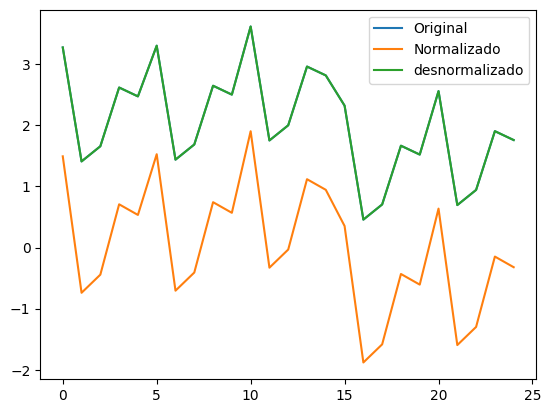

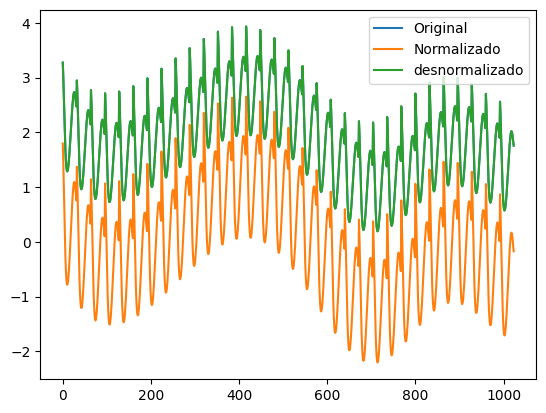

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def function(grid): 
    x = np.linspace(1, 0, grid)
    y = np.linspace(1, 0, grid)
    x, y = np.meshgrid(x, y)
    z = 1.3356 * (1.5 * (1 - x))+np.exp(2 * x - 1) * np.sin(3 * np.pi * (x - 0.6)**2)+np.exp(3*(y - 0.5)) * np.sin(4 * np.pi * (y - 0.9)**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-09 23:14:28.545888: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-09 23:14:28.615735: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-09 23:14:28.615777: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-09 23:14:28.617543: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-09 23:14:28.624258: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-09 23:14:28.624984: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [8]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.6,
            hidden_sizes = [[15], [16], [17], [18], [19], [20], [21]],
            regularizers=[0.5, 0.3],
            learning_rate=[0.1, 0.5])

Testando combinacao1: Hidden Size=[15], regularizer=0.5, learning_rate=0.1
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_17,0.619790,0.213493,0.361454,-0.684552,-0.235635,0.225709,0.466904,0.199962,1.171607,0.685784,0.127600,0.475089,1.246623,0.495314,124.977016,199.328441
model_1_0_18,0.620407,0.213207,0.368722,-0.695198,-0.240255,0.225343,0.467074,0.197685,1.179012,0.688349,0.122120,0.474703,1.246223,0.494912,124.980265,199.331690
model_1_0_16,0.618558,0.213205,0.351956,-0.673686,-0.231506,0.226440,0.467076,0.202936,1.164050,0.683493,0.133684,0.475857,1.247422,0.496116,124.970548,199.321974
model_1_0_19,0.620561,0.212505,0.374206,-0.705491,-0.245157,0.225251,0.467491,0.195968,1.186170,0.691069,0.117184,0.474607,1.246123,0.494812,124.981077,199.332502
model_1_0_15,0.616538,0.212158,0.339729,-0.662729,-0.228090,0.227640,0.467697,0.206764,1.156429,0.681597,0.140437,0.477116,1.248732,0.497428,124.959982,199.311407
model_1_0_20,0.620378,0.211519,0.378288,-0.715311,-0.250159,0.225360,0.468076,0.194690,1.193000,0.693845,0.112740,0.474721,1.246241,0.494931,124.980113,199.331538
model_1_0_21,0.619960,0.210355,0.381287,-0.724569,-0.255113,0.225608,0.468767,0.193751,1.199439,0.696595,0.108737,0.474982,1.246512,0.495203,124.977913,199.329338
model_1_0_14,0.613532,0.210149,0.324219,-0.651751,-0.225587,0.229424,0.468889,0.211621,1.148794,0.680208,0.147929,0.478982,1.250682,0.499373,124.944368,199.295794
model_1_0_22,0.619386,0.209094,0.383463,-0.733215,-0.259916,0.225949,0.469516,0.193069,1.205452,0.699261,0.105133,0.475341,1.246885,0.495577,124.974893,199.326319
model_1_0_23,0.618716,0.207795,0.385016,-0.741220,-0.264494,0.226347,0.470287,0.192583,1.211020,0.701801,0.101888,0.475759,1.247320,0.496013,124.971373,199.322799


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_24,0.916231,0.708463,-1.077085,0.881427,0.535419,0.049729,0.173069,0.241772,0.061130,0.151451,0.062091,0.223000,1.054337,0.232493,128.002341,202.353767
model_1_1_23,0.916489,0.707024,-1.060357,0.883082,0.539715,0.049576,0.173923,0.239825,0.060277,0.150051,0.062614,0.222657,1.054170,0.232136,128.008499,202.359924
model_1_1_22,0.916730,0.705377,-1.041751,0.885031,0.544577,0.049433,0.174901,0.237660,0.059273,0.148466,0.063176,0.222335,1.054013,0.231800,128.014286,202.365712
model_1_1_21,0.916943,0.703485,-1.021052,0.887330,0.550090,0.049306,0.176024,0.235250,0.058088,0.146669,0.063778,0.222050,1.053875,0.231503,128.019409,202.370834
model_1_1_20,0.917112,0.701305,-0.998007,0.890046,0.556352,0.049206,0.177318,0.232568,0.056687,0.144627,0.064418,0.221824,1.053765,0.231268,128.023482,202.374907
model_1_1_19,0.917216,0.698784,-0.972348,0.893259,0.563474,0.049144,0.178815,0.229581,0.055031,0.142306,0.065092,0.221685,1.053698,0.231123,128.025983,202.377408
model_1_1_18,0.917226,0.695854,-0.943768,0.897055,0.571578,0.049138,0.180554,0.226254,0.053073,0.139664,0.065792,0.221672,1.053692,0.231109,128.026226,202.377651
model_1_1_17,0.917104,0.692432,-0.911942,0.901531,0.580799,0.049210,0.182586,0.222550,0.050766,0.136658,0.066511,0.221834,1.053770,0.231278,128.023300,202.374725
model_1_1_16,0.916801,0.688412,-0.876498,0.906779,0.591277,0.049391,0.184972,0.218424,0.048060,0.133242,0.067234,0.222240,1.053967,0.231701,128.015994,202.367419
model_1_1_15,0.916247,0.683659,-0.837032,0.912882,0.603148,0.049719,0.187794,0.213830,0.044914,0.129372,0.067943,0.222978,1.054326,0.232471,128.002729,202.354154


DataFrame salvo em content/results/metrics_1_1
+++++++++++ [1_2] | 1 ++++++++++++++++++
Stopped at epoch:  9
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_2] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 9 +++++++++++

...

DataFrame salvo em content/results/metrics_28_7
+++++++++++ [28_8] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_8_0,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_22,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_21,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_20,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_19,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_18,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_17,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_16,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_15,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_8_14,0.991501,0.668239,1.0,0.99977,0.999915,0.005045,0.196948,1.295756e-14,0.000097,0.000048,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071


DataFrame salvo em content/results/metrics_28_8
+++++++++++ [28_9] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_9_0,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_22,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_21,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_20,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_19,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_18,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_17,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_16,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_15,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071
model_28_9_14,0.991501,0.668239,0.989983,0.983799,0.987845,0.005045,0.196948,0.00993,0.008756,0.009343,0.018902,0.07103,1.003344,0.074054,180.578626,284.183071


DataFrame salvo em content/results/metrics_28_9
